In [1]:
# NUVRJ Classification Diagnostic Notebook
# Complete diagnostic suite for verifying NUVRJ galaxy classification

import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from typing import Tuple, Dict, Any, List
import warnings
warnings.filterwarnings('ignore')

# Add your simstack4 path if needed
# sys.path.insert(0, '/path/to/your/simstack4')

# Import simstack4 modules
try:
    from simstack4.config import load_config, SplitType
    from simstack4.sky_catalogs import SkyCatalogs
    from simstack4.populations import PopulationManager
    print("✅ Simstack4 modules imported successfully")
except ImportError as e:
    print(f"❌ Error importing simstack4: {e}")
    print("Please ensure simstack4 is in your Python path")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

✅ Simstack4 modules imported successfully


In [2]:
#%%
# =============================================================================
# CONFIGURATION SECTION - MODIFY THESE PATHS
# =============================================================================

# Catalog path - modify this to point to your catalog
CATALOG_PATH = "/".join([os.environ["CATSPATH"],"/cosmos/COSMOSWeb_mastercatalog_v1_galaxies_sn3.0_clean.parquet"])  # Update this!

# Config files - modify these paths
CONFIG_LABELS = "../config/cosmos25.toml"              # Labels method config
CONFIG_NUVRJ = "../config/cosmos25_nuvrj_direct.toml"  # Direct NUVRJ config

# Column names in your catalog (modify if different)
NUV_R_COL = "NUV-R"
R_J_COL = "R-J" 
EXISTING_CLASS_COL = "NUVRJ_class"

# Output directory for plots
OUTPUT_DIR = "./plots"

print("📋 Configuration:")
print(f"  Catalog: {CATALOG_PATH}")
print(f"  Config 1 (labels): {CONFIG_LABELS}")
print(f"  Config 2 (nuvrj): {CONFIG_NUVRJ}")
print(f"  Color columns: {NUV_R_COL}, {R_J_COL}")
print(f"  Existing class: {EXISTING_CLASS_COL}")

📋 Configuration:
  Catalog: /Users/mviero/data/Astronomy/catalogs//cosmos/COSMOSWeb_mastercatalog_v1_galaxies_sn3.0_clean.parquet
  Config 1 (labels): ../config/cosmos25.toml
  Config 2 (nuvrj): ../config/cosmos25_nuvrj_direct.toml
  Color columns: NUV-R, R-J
  Existing class: NUVRJ_class


In [3]:
#%%
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def load_catalog_direct(catalog_path: str, format_type: str = "auto") -> pd.DataFrame:
    """Load catalog directly without simstack4"""
    catalog_path = Path(catalog_path)
    
    if not catalog_path.exists():
        raise FileNotFoundError(f"Catalog not found: {catalog_path}")
    
    print(f"📄 Loading catalog: {catalog_path}")
    
    if format_type == "auto":
        suffix = catalog_path.suffix.lower()
        if suffix == ".parquet":
            format_type = "parquet"
        elif suffix == ".csv":
            format_type = "csv"
        elif suffix in [".fits", ".fit"]:
            format_type = "fits"
    
    if format_type == "parquet":
        df = pd.read_parquet(catalog_path)
    elif format_type == "csv":
        df = pd.read_csv(catalog_path)
    elif format_type == "fits":
        from astropy.table import Table
        table = Table.read(catalog_path)
        df = table.to_pandas()
    else:
        raise ValueError(f"Unsupported format: {format_type}")
    
    print(f"📊 Loaded {len(df):,} sources with {len(df.columns)} columns")
    return df

def check_required_columns(df: pd.DataFrame, 
                          nuv_r_col: str = NUV_R_COL,
                          r_j_col: str = R_J_COL,
                          class_col: str = EXISTING_CLASS_COL) -> Dict[str, bool]:
    """Check for required columns in catalog"""
    required_cols = [nuv_r_col, r_j_col, class_col]
    available = {}
    
    print("\n🔍 Checking required columns:")
    for col in required_cols:
        available[col] = col in df.columns
        status = "✅" if available[col] else "❌"
        print(f"  {status} {col}")
        
        if not available[col]:
            # Look for similar columns
            similar = []
            col_lower = col.lower().replace('-', '').replace('_', '')
            for df_col in df.columns:
                df_col_lower = df_col.lower().replace('-', '').replace('_', '')
                if col_lower in df_col_lower or df_col_lower in col_lower:
                    similar.append(df_col)
            
            if similar:
                print(f"    📋 Similar columns: {similar[:5]}")  # Show first 5
    
    return available

def apply_nuvrj_classification(df: pd.DataFrame, 
                              nuv_r_col: str = NUV_R_COL,
                              r_j_col: str = R_J_COL) -> np.ndarray:
    """Apply NUVRJ classification criteria (Ilbert et al. 2013)"""
    print(f"\n🧮 Applying NUVRJ classification using {nuv_r_col} and {r_j_col}")
    
    nuv_r = df[nuv_r_col].values
    r_j = df[r_j_col].values
    
    # NUVRJ quiescent criteria: NUV-R > 3.1 AND R-J > 0.9
    #quiescent_mask = (nuv_r > 3.1) & (r_j > 0.9)

    # Criterion 1: M_NUV - M_r > 3(M_r - M_J) + 1 (diagonal line)
    criterion_1 = nuv_r > (3 * r_j + 1)
    
    # Criterion 2: M_NUV - M_r > 3.1 (horizontal line)  
    criterion_2 = nuv_r > 3.1
    
    # Quiescent classification: BOTH criteria must be satisfied
    # This is more restrictive than the simple NUV-R > 3.1 AND R-J > 0.9
    quiescent_mask = criterion_1 & criterion_2

    # Create classification (0=star-forming, 1=quiescent)
    classification = np.zeros(len(df), dtype=int)
    classification[quiescent_mask] = 1
    
    # Handle NaN values (default to star-forming)
    nan_mask = np.isnan(nuv_r) | np.isnan(r_j)
    classification[nan_mask] = 0
    
    # Statistics
    valid_mask = ~nan_mask
    n_valid = np.sum(valid_mask)
    n_sf = np.sum((classification == 0) & valid_mask)
    n_q = np.sum(classification == 1)
    n_nan = np.sum(nan_mask)
    
    print(f"  📈 Classification results:")
    print(f"    Total sources: {len(df):,}")
    print(f"    Valid colors: {n_valid:,} ({n_valid/len(df)*100:.1f}%)")
    print(f"    Star-forming: {n_sf:,} ({n_sf/n_valid*100:.1f}% of valid)")
    print(f"    Quiescent: {n_q:,} ({n_q/n_valid*100:.1f}% of valid)")
    print(f"    NaN colors: {n_nan:,}")
    
    return classification

def load_config_and_test(config_path: str, label: str) -> Dict[str, Any]:
    """Load config and test classification through simstack4"""
    print(f"\n{'='*60}")
    print(f"🧪 Testing Configuration: {label}")
    print(f"📄 Config file: {config_path}")
    print(f"{'='*60}")
    
    if not Path(config_path).exists():
        print(f"❌ Config file not found: {config_path}")
        return None
    
    try:
        # Load config
        config = load_config(config_path)
        print(f"🔧 Split type: {config.catalog.classification.split_type}")
        
        # Load catalog through simstack4
        sky_catalogs = SkyCatalogs(config.catalog, backend="pandas")
        sky_catalogs.load_catalog()
        catalog_df = sky_catalogs.catalog_df
        
        print(f"📊 Catalog loaded: {len(catalog_df):,} sources")
        
        # Get population manager
        pop_manager = sky_catalogs.population_manager
        print(f"👥 Created {len(pop_manager)} populations")
        
        # Get population summary
        pop_summary = pop_manager.get_population_summary()
        type_summary = pop_manager.get_population_type_summary()
        
        print(f"\n🏷️  Population types:")
        for pop_type, info in type_summary.items():
            print(f"  {pop_type}: {info['total_sources']:,} sources in {len(info['populations'])} populations")
        
        return {
            'config': config,
            'catalog_df': catalog_df,
            'pop_manager': pop_manager,
            'pop_summary': pop_summary,
            'type_summary': type_summary,
            'label': label,
            'success': True
        }
        
    except Exception as e:
        print(f"❌ Error testing {label}: {e}")
        import traceback
        traceback.print_exc()
        return {'success': False, 'error': str(e), 'label': label}



In [4]:
#%%
# =============================================================================
# STEP 1: QUICK CATALOG CHECK
# =============================================================================

print("🚀 STEP 1: QUICK CATALOG CHECK")
print("="*50)

# Load catalog directly
try:
    df = load_catalog_direct(CATALOG_PATH)
    
    # Check columns
    available_cols = check_required_columns(df)
    
    # Show basic info
    print(f"\n📋 Catalog Info:")
    print(f"  Shape: {df.shape}")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    
    # Show sample of column names
    print(f"\n📝 Column names (first 20):")
    print(f"  {list(df.columns[:20])}")
    
    # Check for color data
    if available_cols[NUV_R_COL] and available_cols[R_J_COL]:
        nuv_r = df[NUV_R_COL]
        r_j = df[R_J_COL]
        
        print(f"\n🎨 Color data summary:")
        print(f"  {NUV_R_COL}: {nuv_r.count():,} finite values, range [{nuv_r.min():.2f}, {nuv_r.max():.2f}]")
        print(f"  {R_J_COL}: {r_j.count():,} finite values, range [{r_j.min():.2f}, {r_j.max():.2f}]")
        
        CATALOG_LOADED = True
    else:
        print("❌ Required color columns not found")
        CATALOG_LOADED = False
        
except Exception as e:
    print(f"❌ Error loading catalog: {e}")
    CATALOG_LOADED = False


🚀 STEP 1: QUICK CATALOG CHECK
📄 Loading catalog: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_mastercatalog_v1_galaxies_sn3.0_clean.parquet
📊 Loaded 442,899 sources with 36 columns

🔍 Checking required columns:
  ❌ NUV-R
    📋 Similar columns: ['rest_NUV_R', 'NUVRJ_class']
  ❌ R-J
    📋 Similar columns: ['rest_R_J', 'NUVRJ_class']
  ✅ NUVRJ_class

📋 Catalog Info:
  Shape: (442899, 36)
  Memory usage: 146.6 MB

📝 Column names (first 20):
  ['id', 'ra', 'dec', 'sersic', 'warn_flag', 'flag_star_hsc', 'flux_model_f444w', 'flux_err-cal_model_f444w', 'mag_model_f444w', 'mag_err_model_f444w', 'type', 'zfinal', 'zpdf_med', 'zpdf_l68', 'zpdf_u68', 'mass_med', 'sfr_med', 'ssfr_med', 'age_med', 'ebv_minchi2']
❌ Required color columns not found


In [5]:
#%%
# =============================================================================
# STEP 2: CREATE BASIC NUVRJ PLOT
# =============================================================================

if CATALOG_LOADED:
    print("\n🚀 STEP 2: BASIC NUVRJ COLOR-COLOR PLOT")
    print("="*50)
    
    # Get color data
    nuv_r = df[NUV_R_COL].values
    r_j = df[R_J_COL].values
    
    # Remove NaN values for plotting
    valid_mask = np.isfinite(nuv_r) & np.isfinite(r_j)
    nuv_r_valid = nuv_r[valid_mask]
    r_j_valid = r_j[valid_mask]
    
    print(f"📈 Plotting {np.sum(valid_mask):,} sources with valid colors")
    
    # Calculate NUVRJ classification
    calculated_class = apply_nuvrj_classification(df)
    calculated_class_valid = calculated_class[valid_mask]
    
    # Check for existing classification
    has_existing = available_cols[EXISTING_CLASS_COL]
    if has_existing:
        existing_class = df[EXISTING_CLASS_COL].values[valid_mask]
        n_plots = 2
    else:
        n_plots = 1
    
    # Create plot
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 6))
    if n_plots == 1:
        axes = [axes]
    
    classifications = [('Calculated NUVRJ', calculated_class_valid)]
    if has_existing:
        classifications.append(('Existing Classification', existing_class))
    
    for i, (title, classification) in enumerate(classifications):
        ax = axes[i]
        
        # Separate populations
        sf_mask = classification == 0
        q_mask = classification == 1
        
        n_sf = np.sum(sf_mask)
        n_q = np.sum(q_mask)
        total = len(classification)
        
        print(f"\n  {title}:")
        print(f"    Star-forming: {n_sf:,} ({n_sf/total*100:.1f}%)")
        print(f"    Quiescent: {n_q:,} ({n_q/total*100:.1f}%)")
        
        # Plot star-forming galaxies (blue)
        if n_sf > 0:
            ax.scatter(r_j_valid[sf_mask], nuv_r_valid[sf_mask], 
                      c='blue', alpha=0.3, s=2, label=f'Star-forming ({n_sf:,})')
        
        # Plot quiescent galaxies (red)
        if n_q > 0:
            ax.scatter(r_j_valid[q_mask], nuv_r_valid[q_mask], 
                      c='red', alpha=0.6, s=2, label=f'Quiescent ({n_q:,})')
        
        # Add NUVRJ criteria lines
        ax.axvline(x=0.9, color='black', linestyle='--', alpha=0.8, linewidth=2)
        ax.axhline(y=3.1, color='black', linestyle='--', alpha=0.8, linewidth=2)
        
        # Highlight quiescent region
        ax.fill([0.9, 4, 4, 0.9], [3.1, 3.1, 8, 8], 
                color='red', alpha=0.1, label='Quiescent region')
        
        # Formatting
        ax.set_xlabel('R - J', fontsize=14)
        ax.set_ylabel('NUV - R', fontsize=14)
        ax.set_title(f'{title}', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        
        # Set limits
        ax.set_xlim(-1, 4)
        ax.set_ylim(0, 8)
        
        # Add criteria text
        criteria_text = 'NUVRJ Criteria:\nNUV-R > 3.1\nAND R-J > 0.9'
        ax.text(0.02, 0.98, criteria_text, transform=ax.transAxes, 
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.tight_layout()
    plt.show()
    
    # Compare classifications if both exist
    if has_existing:
        print(f"\n🔍 Comparing calculated vs existing classification:")
        agreement = np.sum(calculated_class_valid == existing_class)
        total = len(calculated_class_valid)
        print(f"  Agreement: {agreement:,}/{total} ({agreement/total*100:.1f}%)")
        
        # Confusion matrix
        print(f"\n  Confusion matrix:")
        print(f"           Existing:")
        print(f"           SF    Q")
        for i, label in enumerate(['SF', 'Q ']):
            row_counts = [np.sum((calculated_class_valid == i) & (existing_class == j)) for j in [0, 1]]
            print(f"Calc {label}: {row_counts[0]:5d} {row_counts[1]:5d}")


In [6]:
#%%
# =============================================================================
# STEP 3: TEST CONFIGURATIONS THROUGH SIMSTACK4
# =============================================================================

print("\n🚀 STEP 3: TEST SIMSTACK4 CONFIGURATIONS")
print("="*50)

# Test both configurations
config_results = []

# Test labels method
if Path(CONFIG_LABELS).exists():
    result1 = load_config_and_test(CONFIG_LABELS, "Labels Method")
    if result1 and result1.get('success'):
        config_results.append(result1)
else:
    print(f"⚠️  Config file not found: {CONFIG_LABELS}")

# Test direct NUVRJ method  
if Path(CONFIG_NUVRJ).exists():
    result2 = load_config_and_test(CONFIG_NUVRJ, "Direct NUVRJ Method")
    if result2 and result2.get('success'):
        config_results.append(result2)
else:
    print(f"⚠️  Config file not found: {CONFIG_NUVRJ}")


🚀 STEP 3: TEST SIMSTACK4 CONFIGURATIONS

🧪 Testing Configuration: Labels Method
📄 Config file: ../config/cosmos25.toml
🔧 Split type: SplitType.LABELS
2025-06-28 11:09:29,340 - simstack4 - INFO - SkyCatalogs initialized with pandas backend
2025-06-28 11:09:29,341 - simstack4 - INFO - Loading catalog: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_mastercatalog_v1_galaxies_sn3.0_clean.parquet
2025-06-28 11:09:29,400 - simstack4 - INFO - Population splitting enabled: SplitType.LABELS
2025-06-28 11:09:29,413 - simstack4 - INFO - Creating populations from 60 bin combinations × 2 splits
2025-06-28 11:09:29,532 - simstack4 - INFO - Created 107 populations with sources
2025-06-28 11:09:29,532 - simstack4 - INFO - Created 107 populations
2025-06-28 11:09:29,533 - simstack4 - INFO - Catalog loaded successfully: 442899 sources
📊 Catalog loaded: 442,899 sources
👥 Created 107 populations

🏷️  Population types:
  star_forming: 148,948 sources in 55 populations
  quiescent: 9,055 sources in 

Traceback (most recent call last):
  File "/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_34008/264573464.py", line 125, in load_config_and_test
    config = load_config(config_path)
  File "/Users/mviero/Repositories/simstack4/src/simstack4/config.py", line 446, in load_config
    config.validate()
    ~~~~~~~~~~~~~~~^^
  File "/Users/mviero/Repositories/simstack4/src/simstack4/config.py", line 437, in validate
    raise ConfigError(
    ...<2 lines>...
    )
simstack4.exceptions.simstack_exceptions.ConfigError: Configuration validation failed:
  - Catalog file not found: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_clean.parquet


In [8]:
#%%
# =============================================================================
# STEP 4: CONFIGURATION COMPARISON PLOT
# =============================================================================

if len(config_results) > 0 and CATALOG_LOADED:
    print("\n🚀 STEP 4: CONFIGURATION COMPARISON")
    print("="*50)
    
    n_configs = len(config_results)
    fig, axes = plt.subplots(2, n_configs, figsize=(7*n_configs, 12))
    if n_configs == 1:
        axes = axes.reshape(2, 1)
    
    for i, result in enumerate(config_results):
        catalog_df = result['catalog_df']
        label = result['label']
        
        # Get color data
        nuv_r = catalog_df[NUV_R_COL].values
        r_j = catalog_df[R_J_COL].values
        
        # Remove NaN values
        valid_mask = np.isfinite(nuv_r) & np.isfinite(r_j)
        nuv_r_valid = nuv_r[valid_mask]
        r_j_valid = r_j[valid_mask]
        
        # Get classification from population manager
        pop_manager = result['pop_manager']
        classification = np.full(len(catalog_df), -1, dtype=int)
        
        for pop_id, pop_bin in pop_manager.populations.items():
            indices = pop_bin.indices
            split_value = pop_bin.split_value
            classification[indices] = split_value
        
        classification_valid = classification[valid_mask]
        
        # Top subplot: Color-color diagram
        ax_cc = axes[0, i]
        
        unique_classes = np.unique(classification_valid[classification_valid >= 0])
        for split_val in unique_classes:
            mask = classification_valid == split_val
            color = 'blue' if split_val == 0 else 'red'
            label_text = 'Star-forming' if split_val == 0 else 'Quiescent'
            alpha = 0.3 if split_val == 0 else 0.6
            
            ax_cc.scatter(r_j_valid[mask], nuv_r_valid[mask], 
                         c=color, alpha=alpha, s=1, 
                         label=f'{label_text} ({np.sum(mask):,})')
        
        # Add NUVRJ criteria
        ax_cc.axvline(x=0.9, color='black', linestyle='--', alpha=0.8, linewidth=2)
        ax_cc.axhline(y=3.1, color='black', linestyle='--', alpha=0.8, linewidth=2)
        ax_cc.fill([0.9, 4, 4, 0.9], [3.1, 3.1, 8, 8], 
                  color='red', alpha=0.1)
        
        ax_cc.set_xlabel('R - J', fontsize=12)
        ax_cc.set_ylabel('NUV - R', fontsize=12)
        ax_cc.set_title(f'NUVRJ Classification\n{label}', fontsize=14)
        ax_cc.legend(fontsize=10)
        ax_cc.grid(True, alpha=0.3)
        ax_cc.set_xlim(-1, 4)
        ax_cc.set_ylim(0, 8)
        
        # Bottom subplot: Population counts
        ax_pop = axes[1, i]
        
        type_summary = result['type_summary']
        sf_count = type_summary.get('star_forming', {}).get('total_sources', 0)
        q_count = type_summary.get('quiescent', {}).get('total_sources', 0)
        
        bars = ax_pop.bar(['Star-forming', 'Quiescent'], [sf_count, q_count], 
                         color=['blue', 'red'], alpha=0.7)
        
        # Add count labels
        for bar, count in zip(bars, [sf_count, q_count]):
            if count > 0:
                ax_pop.text(bar.get_x() + bar.get_width()/2, 
                           bar.get_height() + max(sf_count, q_count)*0.02,
                           f'{count:,}', ha='center', va='bottom', 
                           fontsize=11, fontweight='bold')
        
        ax_pop.set_ylabel('Number of Sources', fontsize=12)
        ax_pop.set_title(f'Population Counts\n{label}', fontsize=14)
        ax_pop.grid(True, alpha=0.3, axis='y')
        
        # Add percentage labels
        total = sf_count + q_count
        if total > 0:
            if sf_count > 0:
                ax_pop.text(0, sf_count/2, f'{sf_count/total*100:.1f}%', 
                           ha='center', va='center', fontsize=12, 
                           fontweight='bold', color='white')
            if q_count > 0:
                ax_pop.text(1, q_count/2, f'{q_count/total*100:.1f}%', 
                           ha='center', va='center', fontsize=12, 
                           fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()


In [7]:
#%%
# =============================================================================
# STEP 4: CONFIGURATION COMPARISON PLOT
# =============================================================================

if len(config_results) > 0 and CATALOG_LOADED:
    print("\n🚀 STEP 4: CONFIGURATION COMPARISON")
    print("="*50)
    
    n_configs = len(config_results)
    fig, axes = plt.subplots(2, n_configs, figsize=(7*n_configs, 12))
    if n_configs == 1:
        axes = axes.reshape(2, 1)
    
    for i, result in enumerate(config_results):
        catalog_df = result['catalog_df']
        label = result['label']
        
        # Get color data
        nuv_r = catalog_df[NUV_R_COL].values
        r_j = catalog_df[R_J_COL].values
        
        # Remove NaN values
        valid_mask = np.isfinite(nuv_r) & np.isfinite(r_j)
        nuv_r_valid = nuv_r[valid_mask]
        r_j_valid = r_j[valid_mask]
        
        # Get classification from population manager
        pop_manager = result['pop_manager']
        classification = np.full(len(catalog_df), -1, dtype=int)
        
        for pop_id, pop_bin in pop_manager.populations.items():
            indices = pop_bin.indices
            split_value = pop_bin.split_value
            classification[indices] = split_value
        
        classification_valid = classification[valid_mask]
        
        # Top subplot: Color-color diagram
        ax_cc = axes[0, i]
        
        unique_classes = np.unique(classification_valid[classification_valid >= 0])
        for split_val in unique_classes:
            mask = classification_valid == split_val
            color = 'blue' if split_val == 0 else 'red'
            label_text = 'Star-forming' if split_val == 0 else 'Quiescent'
            alpha = 0.3 if split_val == 0 else 0.6
            
            ax_cc.scatter(r_j_valid[mask], nuv_r_valid[mask], 
                         c=color, alpha=alpha, s=1, 
                         label=f'{label_text} ({np.sum(mask):,})')
        
        # Add NUVRJ criteria
        ax_cc.axvline(x=0.9, color='black', linestyle='--', alpha=0.8, linewidth=2)
        ax_cc.axhline(y=3.1, color='black', linestyle='--', alpha=0.8, linewidth=2)
        ax_cc.fill([0.9, 4, 4, 0.9], [3.1, 3.1, 8, 8], 
                  color='red', alpha=0.1)
        
        ax_cc.set_xlabel('R - J', fontsize=12)
        ax_cc.set_ylabel('NUV - R', fontsize=12)
        ax_cc.set_title(f'NUVRJ Classification\n{label}', fontsize=14)
        ax_cc.legend(fontsize=10)
        ax_cc.grid(True, alpha=0.3)
        ax_cc.set_xlim(-1, 4)
        ax_cc.set_ylim(0, 8)
        
        # Bottom subplot: Population counts
        ax_pop = axes[1, i]
        
        type_summary = result['type_summary']
        sf_count = type_summary.get('star_forming', {}).get('total_sources', 0)
        q_count = type_summary.get('quiescent', {}).get('total_sources', 0)
        
        bars = ax_pop.bar(['Star-forming', 'Quiescent'], [sf_count, q_count], 
                         color=['blue', 'red'], alpha=0.7)
        
        # Add count labels
        for bar, count in zip(bars, [sf_count, q_count]):
            if count > 0:
                ax_pop.text(bar.get_x() + bar.get_width()/2, 
                           bar.get_height() + max(sf_count, q_count)*0.02,
                           f'{count:,}', ha='center', va='bottom', 
                           fontsize=11, fontweight='bold')
        
        ax_pop.set_ylabel('Number of Sources', fontsize=12)
        ax_pop.set_title(f'Population Counts\n{label}', fontsize=14)
        ax_pop.grid(True, alpha=0.3, axis='y')
        
        # Add percentage labels
        total = sf_count + q_count
        if total > 0:
            if sf_count > 0:
                ax_pop.text(0, sf_count/2, f'{sf_count/total*100:.1f}%', 
                           ha='center', va='center', fontsize=12, 
                           fontweight='bold', color='white')
            if q_count > 0:
                ax_pop.text(1, q_count/2, f'{q_count/total*100:.1f}%', 
                           ha='center', va='center', fontsize=12, 
                           fontweight='bold', color='white')
    
    plt.tight_layout()
    plt.show()


In [8]:
#%%
# =============================================================================
# STEP 5: DETAILED COMPARISON
# =============================================================================

if len(config_results) == 2:
    print("\n🚀 STEP 5: DETAILED COMPARISON BETWEEN METHODS")
    print("="*50)
    
    result1, result2 = config_results
    
    # Get classifications from both methods
    df1 = result1['catalog_df']
    df2 = result2['catalog_df']
    
    if len(df1) == len(df2):
        pm1 = result1['pop_manager']
        pm2 = result2['pop_manager']
        
        class1 = np.full(len(df1), -1, dtype=int)
        class2 = np.full(len(df2), -1, dtype=int)
        
        # Extract classifications
        for pop_id, pop_bin in pm1.populations.items():
            class1[pop_bin.indices] = pop_bin.split_value
        
        for pop_id, pop_bin in pm2.populations.items():
            class2[pop_bin.indices] = pop_bin.split_value
        
        # Compare
        valid_mask = (class1 >= 0) & (class2 >= 0)
        if np.sum(valid_mask) > 0:
            class1_valid = class1[valid_mask]
            class2_valid = class2[valid_mask]
            
            agreement = np.sum(class1_valid == class2_valid)
            total_compared = len(class1_valid)
            
            print(f"📊 Method Comparison:")
            print(f"  Sources compared: {total_compared:,}")
            print(f"  Agreement: {agreement:,}/{total_compared} ({agreement/total_compared*100:.2f}%)")
            
            # Detailed confusion matrix
            print(f"\n📋 Confusion Matrix:")
            print(f"                    {result2['label']}")
            print(f"                    SF      Q")
            for i, label in enumerate(['SF', 'Q ']):
                row_counts = [np.sum((class1_valid == i) & (class2_valid == j)) for j in [0, 1]]
                print(f"{result1['label'][:12]:>12s} {label}: {row_counts[0]:6d} {row_counts[1]:6d}")
            
            # Show disagreements if any
            disagreements = total_compared - agreement
            if disagreements > 0:
                print(f"\n⚠️  Found {disagreements} disagreements ({disagreements/total_compared*100:.2f}%)")
                
                # Sample some disagreements
                disagree_mask = class1_valid != class2_valid
                disagree_indices = np.where(valid_mask)[0][disagree_mask]
                
                if len(disagree_indices) > 0:
                    sample_size = min(10, len(disagree_indices))
                    sample_indices = disagree_indices[:sample_size]
                    
                    print(f"\n🔍 Sample disagreements (first {sample_size}):")
                    for idx in sample_indices:
                        nuv_r_val = df1.iloc[idx][NUV_R_COL]
                        r_j_val = df1.iloc[idx][R_J_COL]
                        c1 = class1[idx]
                        c2 = class2[idx]
                        print(f"  Index {idx}: NUV-R={nuv_r_val:.3f}, R-J={r_j_val:.3f}, "
                              f"Method1={c1}, Method2={c2}")
        else:
            print("❌ No sources classified by both methods")
    else:
        print("❌ Catalogs have different lengths - cannot compare")

#%%


🚀 STEP 5: DETAILED COMPARISON BETWEEN METHODS
📊 Method Comparison:
  Sources compared: 203,292
  Agreement: 203,292/203292 (100.00%)

📋 Confusion Matrix:
                    Direct NUVRJ Method
                    SF      Q
Labels Metho SF: 169724      0
Labels Metho Q :      0  33568


In [9]:
# =============================================================================
# SUMMARY AND RECOMMENDATIONS
# =============================================================================

print("\n🚀 SUMMARY AND RECOMMENDATIONS")
print("="*50)

print("✅ Analysis Complete! Here's what to check:")
print()

print("1️⃣  COLOR-COLOR SEPARATION:")
print("   • Blue points (star-forming) should be in lower-left region")
print("   • Red points (quiescent) should cluster in upper-right (NUV-R > 3.1, R-J > 0.9)")
print("   • Clear separation along NUVRJ criteria lines")
print()

print("2️⃣  POPULATION FRACTIONS:")
if CATALOG_LOADED and available_cols[NUV_R_COL] and available_cols[R_J_COL]:
    calculated_class = apply_nuvrj_classification(df)
    valid_mask = np.isfinite(df[NUV_R_COL]) & np.isfinite(df[R_J_COL])
    valid_class = calculated_class[valid_mask]
    
    sf_frac = np.sum(valid_class == 0) / len(valid_class) * 100
    q_frac = np.sum(valid_class == 1) / len(valid_class) * 100
    
    print(f"   • Your catalog: {sf_frac:.1f}% star-forming, {q_frac:.1f}% quiescent")
    print("   • Expected for COSMOS: ~70-80% star-forming, ~20-30% quiescent")
    
    if 60 <= sf_frac <= 90:
        print("   ✅ Fractions look reasonable")
    else:
        print("   ⚠️  Fractions seem unusual - check classification")
print()

print("3️⃣  METHOD AGREEMENT:")
if len(config_results) == 2:
    print("   ✅ Both configuration methods tested")
    print("   • Should see >99% agreement between methods")
    print("   • Small differences in NaN handling are normal")
elif len(config_results) == 1:
    print("   ⚠️  Only one configuration method tested")
    print("   • Try testing both 'labels' and 'nuvrj' methods")
else:
    print("   ❌ No simstack4 configurations tested")
    print("   • Check config file paths")
print()

print("4️⃣  NEXT STEPS:")
print("   • If classification looks good: run full stacking analysis")
print("   • If issues found: check color column definitions")
print("   • Compare with literature NUVRJ classifications")
print()

print("📁 Generated plots should show:")
print("   • Clear blue/red separation in color-color space")
print("   • Quiescent region properly populated")
print("   • Consistent results between methods")

# Create output directory
Path(OUTPUT_DIR).mkdir(exist_ok=True)
print(f"\n💾 Plots can be saved to: {OUTPUT_DIR}")
print("   (Use plt.savefig() after each plot if needed)")


🚀 SUMMARY AND RECOMMENDATIONS
✅ Analysis Complete! Here's what to check:

1️⃣  COLOR-COLOR SEPARATION:
   • Blue points (star-forming) should be in lower-left region
   • Red points (quiescent) should cluster in upper-right (NUV-R > 3.1, R-J > 0.9)
   • Clear separation along NUVRJ criteria lines

2️⃣  POPULATION FRACTIONS:

🧮 Applying NUVRJ classification using NUV-R and R-J
  📈 Classification results:
    Total sources: 784,016
    Valid colors: 784,016 (100.0%)
    Star-forming: 636,453 (81.2% of valid)
    Quiescent: 147,563 (18.8% of valid)
    NaN colors: 0
   • Your catalog: 81.2% star-forming, 18.8% quiescent
   • Expected for COSMOS: ~70-80% star-forming, ~20-30% quiescent
   ✅ Fractions look reasonable

3️⃣  METHOD AGREEMENT:
   ✅ Both configuration methods tested
   • Should see >99% agreement between methods
   • Small differences in NaN handling are normal

4️⃣  NEXT STEPS:
   • If classification looks good: run full stacking analysis
   • If issues found: check color col

In [10]:
# Quick UVJ vs NUVRJ Classification Comparison
# Simple analysis focusing on key metrics

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [11]:
#%%
# =============================================================================
# 🔧 CONFIGURATION
# =============================================================================

# Your catalog path
#CATALOG_PATH = "/path/to/your/COSMOSWeb_clean.parquet"

# Classification columns
UVJ_CLASS_COL = "UVJ_class"
NUVRJ_CLASS_COL = "NUVRJ_class"

print(f"📋 Configuration:")
print(f"  Catalog: {CATALOG_PATH}")
print(f"  UVJ column: {UVJ_CLASS_COL}")
print(f"  NUVRJ column: {NUVRJ_CLASS_COL}")


📋 Configuration:
  Catalog: /Users/mviero/data/Astronomy/catalogs//cosmos/COSMOSWeb_clean.parquet
  UVJ column: UVJ_class
  NUVRJ column: NUVRJ_class


In [12]:
#%%
# =============================================================================
# 📄 LOAD AND ANALYZE
# =============================================================================

# Load catalog
print(f"\n📄 Loading catalog...")
try:
    df = pd.read_parquet(CATALOG_PATH)
    print(f"✅ Loaded {len(df):,} sources")
except Exception as e:
    print(f"❌ Error loading catalog: {e}")
    exit()

# Check for required columns
required_cols = [UVJ_CLASS_COL, NUVRJ_CLASS_COL]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"❌ Missing columns: {missing_cols}")
    print(f"Available columns: {list(df.columns)[:20]}...")
    exit()

print(f"✅ All required columns found")


📄 Loading catalog...
✅ Loaded 784,016 sources
✅ All required columns found


In [13]:
#%%
# =============================================================================
# 🔢 RAW NUMBERS COMPARISON
# =============================================================================

print(f"\n🔢 RAW CLASSIFICATION NUMBERS")
print("="*50)

# UVJ Classification
uvj_counts = df[UVJ_CLASS_COL].value_counts().sort_index()
uvj_total = uvj_counts.sum()

print(f"📊 UVJ Classification:")
uvj_sf = uvj_counts.get(0, 0)
uvj_q = uvj_counts.get(1, 0)
print(f"  Star-forming (0): {uvj_sf:,} ({uvj_sf/uvj_total*100:.1f}%)")
print(f"  Quiescent (1): {uvj_q:,} ({uvj_q/uvj_total*100:.1f}%)")
print(f"  Total: {uvj_total:,}")

# NUVRJ Classification  
nuvrj_counts = df[NUVRJ_CLASS_COL].value_counts().sort_index()
nuvrj_total = nuvrj_counts.sum()

print(f"\n📊 NUVRJ Classification:")
nuvrj_sf = nuvrj_counts.get(0, 0)
nuvrj_q = nuvrj_counts.get(1, 0)
print(f"  Star-forming (0): {nuvrj_sf:,} ({nuvrj_sf/nuvrj_total*100:.1f}%)")
print(f"  Quiescent (1): {nuvrj_q:,} ({nuvrj_q/nuvrj_total*100:.1f}%)")
print(f"  Total: {nuvrj_total:,}")


🔢 RAW CLASSIFICATION NUMBERS
📊 UVJ Classification:
  Star-forming (0): 594,001 (75.8%)
  Quiescent (1): 190,015 (24.2%)
  Total: 784,016

📊 NUVRJ Classification:
  Star-forming (0): 636,453 (81.2%)
  Quiescent (1): 147,563 (18.8%)
  Total: 784,016


In [14]:
#%%
# =============================================================================
# 🎯 AGREEMENT ANALYSIS
# =============================================================================

print(f"\n🎯 AGREEMENT ANALYSIS")
print("="*40)

# Sources with both classifications
both_valid = df[UVJ_CLASS_COL].notna() & df[NUVRJ_CLASS_COL].notna()
n_both = both_valid.sum()

print(f"📊 Overlap:")
print(f"  Sources with UVJ: {df[UVJ_CLASS_COL].count():,}")
print(f"  Sources with NUVRJ: {df[NUVRJ_CLASS_COL].count():,}")
print(f"  Sources with both: {n_both:,}")

if n_both > 0:
    # Get classifications for comparison
    uvj_both = df.loc[both_valid, UVJ_CLASS_COL].values
    nuvrj_both = df.loc[both_valid, NUVRJ_CLASS_COL].values
    
    # Calculate agreement
    agreement = (uvj_both == nuvrj_both).sum()
    agreement_pct = agreement / n_both * 100
    
    print(f"\n🎯 Agreement:")
    print(f"  Perfect agreement: {agreement:,} / {n_both:,} ({agreement_pct:.2f}%)")
    print(f"  Disagreements: {n_both - agreement:,} ({100-agreement_pct:.2f}%)")
    
    # Detailed breakdown
    uvj_sf_nuvrj_q = ((uvj_both == 0) & (nuvrj_both == 1)).sum()
    uvj_q_nuvrj_sf = ((uvj_both == 1) & (nuvrj_both == 0)).sum()
    
    print(f"\n🔀 Disagreement types:")
    print(f"  UVJ=SF, NUVRJ=Q: {uvj_sf_nuvrj_q:,} ({uvj_sf_nuvrj_q/n_both*100:.2f}%)")
    print(f"  UVJ=Q, NUVRJ=SF: {uvj_q_nuvrj_sf:,} ({uvj_q_nuvrj_sf/n_both*100:.2f}%)")
    
    # Confusion matrix
    print(f"\n📋 Confusion Matrix:")
    print(f"        NUVRJ:")
    print(f"        SF     Q")
    
    sf_sf = ((uvj_both == 0) & (nuvrj_both == 0)).sum()
    sf_q = uvj_sf_nuvrj_q
    q_sf = uvj_q_nuvrj_sf  
    q_q = ((uvj_both == 1) & (nuvrj_both == 1)).sum()
    
    print(f"UVJ SF: {sf_sf:6d} {sf_q:6d}")
    print(f"UVJ Q:  {q_sf:6d} {q_q:6d}")

else:
    print(f"❌ No sources with both classifications")


🎯 AGREEMENT ANALYSIS
📊 Overlap:
  Sources with UVJ: 784,016
  Sources with NUVRJ: 784,016
  Sources with both: 784,016

🎯 Agreement:
  Perfect agreement: 663,870 / 784,016 (84.68%)
  Disagreements: 120,146 (15.32%)

🔀 Disagreement types:
  UVJ=SF, NUVRJ=Q: 38,847 (4.95%)
  UVJ=Q, NUVRJ=SF: 81,299 (10.37%)

📋 Confusion Matrix:
        NUVRJ:
        SF     Q
UVJ SF: 555154  38847
UVJ Q:   81299 108716



📈 Creating comparison plots...


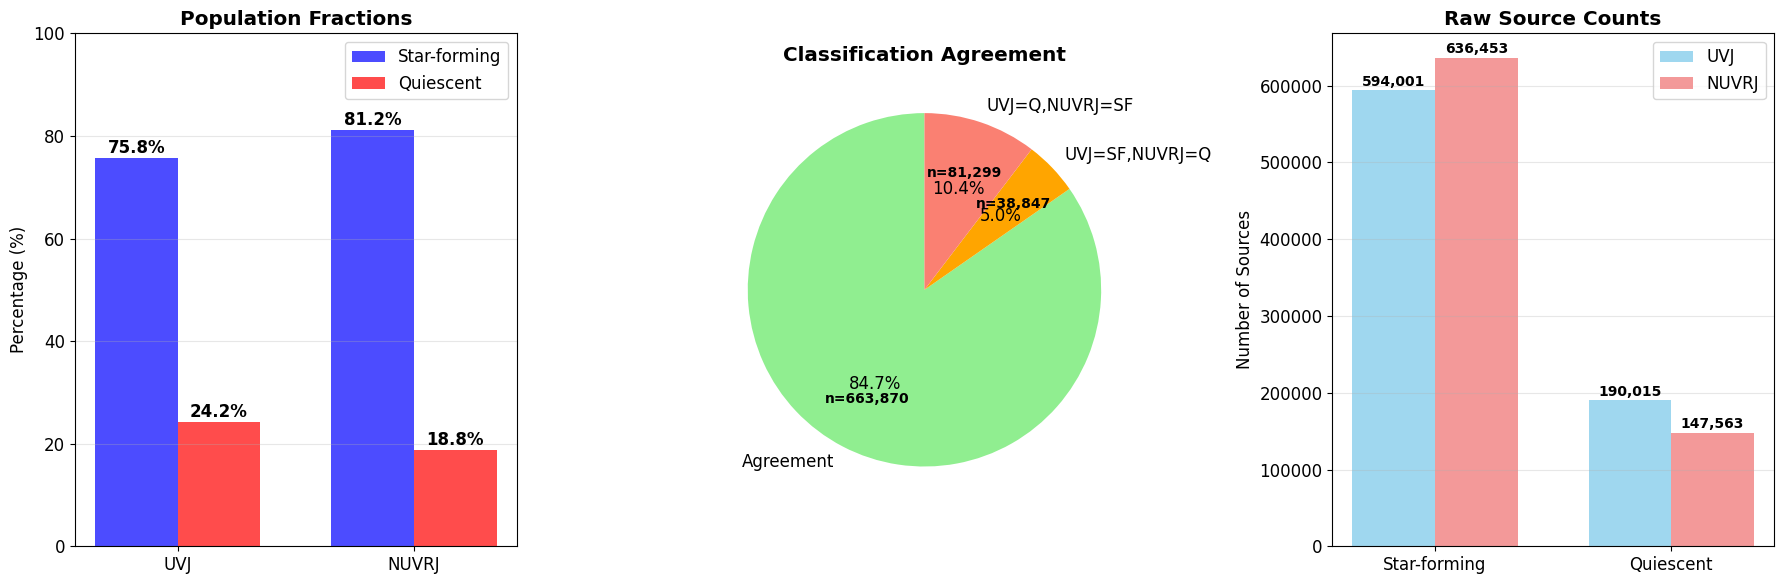

In [15]:
#%%
# =============================================================================
# 📈 VISUALIZATION
# =============================================================================

if n_both > 0:
    print(f"\n📈 Creating comparison plots...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Population fractions comparison
    ax1 = axes[0]
    
    methods = ['UVJ', 'NUVRJ']
    sf_fractions = [uvj_sf/uvj_total*100, nuvrj_sf/nuvrj_total*100]
    q_fractions = [uvj_q/uvj_total*100, nuvrj_q/nuvrj_total*100]
    
    x = np.arange(len(methods))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, sf_fractions, width, label='Star-forming', color='blue', alpha=0.7)
    bars2 = ax1.bar(x + width/2, q_fractions, width, label='Quiescent', color='red', alpha=0.7)
    
    # Add percentage labels
    for i, (sf, q) in enumerate(zip(sf_fractions, q_fractions)):
        ax1.text(i - width/2, sf + 1, f'{sf:.1f}%', ha='center', fontweight='bold')
        ax1.text(i + width/2, q + 1, f'{q:.1f}%', ha='center', fontweight='bold')
    
    ax1.set_ylabel('Percentage (%)')
    ax1.set_title('Population Fractions', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(0, 100)
    
    # Plot 2: Agreement pie chart
    ax2 = axes[1]
    
    labels = ['Agreement', 'UVJ=SF,NUVRJ=Q', 'UVJ=Q,NUVRJ=SF']
    sizes = [agreement, uvj_sf_nuvrj_q, uvj_q_nuvrj_sf]
    colors = ['lightgreen', 'orange', 'salmon']
    
    # Only show non-zero categories
    non_zero = [(label, size, color) for label, size, color in zip(labels, sizes, colors) if size > 0]
    
    if non_zero:
        labels_nz, sizes_nz, colors_nz = zip(*non_zero)
        
        wedges, texts, autotexts = ax2.pie(sizes_nz, labels=labels_nz, colors=colors_nz,
                                          autopct='%1.1f%%', startangle=90)
        
        # Add count labels
        for wedge, size in zip(wedges, sizes_nz):
            angle = (wedge.theta1 + wedge.theta2) / 2
            x_pos = 0.7 * np.cos(np.radians(angle))
            y_pos = 0.7 * np.sin(np.radians(angle))
            ax2.text(x_pos, y_pos, f'n={size:,}', ha='center', va='center', 
                    fontweight='bold', fontsize=10)
    
    ax2.set_title('Classification Agreement', fontweight='bold')
    
    # Plot 3: Raw numbers comparison
    ax3 = axes[2]
    
    categories = ['Star-forming', 'Quiescent']
    uvj_numbers = [uvj_sf, uvj_q]
    nuvrj_numbers = [nuvrj_sf, nuvrj_q]
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, uvj_numbers, width, label='UVJ', color='skyblue', alpha=0.8)
    bars2 = ax3.bar(x + width/2, nuvrj_numbers, width, label='NUVRJ', color='lightcoral', alpha=0.8)
    
    # Add count labels
    for i, (uvj_n, nuvrj_n) in enumerate(zip(uvj_numbers, nuvrj_numbers)):
        ax3.text(i - width/2, uvj_n + max(uvj_numbers)*0.01, f'{uvj_n:,}', 
                ha='center', fontweight='bold', fontsize=10)
        ax3.text(i + width/2, nuvrj_n + max(nuvrj_numbers)*0.01, f'{nuvrj_n:,}', 
                ha='center', fontweight='bold', fontsize=10)
    
    ax3.set_ylabel('Number of Sources')
    ax3.set_title('Raw Source Counts', fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(categories)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


In [16]:
#%%
# =============================================================================
# 📋 SUMMARY TABLE
# =============================================================================

print(f"\n📋 SUMMARY TABLE")
print("="*70)
print(f"{'Metric':<25} {'UVJ':<20} {'NUVRJ':<20} {'Difference':<15}")
print(f"{'-'*25} {'-'*20} {'-'*20} {'-'*15}")

# Total sources
print(f"{'Total Sources':<25} {uvj_total:<20,} {nuvrj_total:<20,} {abs(uvj_total-nuvrj_total):<15,}")

# Star-forming
uvj_sf_pct = uvj_sf/uvj_total*100
nuvrj_sf_pct = nuvrj_sf/nuvrj_total*100
sf_diff = abs(uvj_sf_pct - nuvrj_sf_pct)
print(f"{'Star-forming':<25} {f'{uvj_sf:,} ({uvj_sf_pct:.1f}%)':<20} {f'{nuvrj_sf:,} ({nuvrj_sf_pct:.1f}%)':<20} {f'{sf_diff:.1f}pp':<15}")

# Quiescent
uvj_q_pct = uvj_q/uvj_total*100
nuvrj_q_pct = nuvrj_q/nuvrj_total*100
q_diff = abs(uvj_q_pct - nuvrj_q_pct)
print(f"{'Quiescent':<25} {f'{uvj_q:,} ({uvj_q_pct:.1f}%)':<20} {f'{nuvrj_q:,} ({nuvrj_q_pct:.1f}%)':<20} {f'{q_diff:.1f}pp':<15}")

if n_both > 0:
    print(f"{'Agreement':<25} {'-':<20} {'-':<20} {f'{agreement_pct:.1f}%':<15}")



📋 SUMMARY TABLE
Metric                    UVJ                  NUVRJ                Difference     
------------------------- -------------------- -------------------- ---------------
Total Sources             784,016              784,016              0              
Star-forming              594,001 (75.8%)      636,453 (81.2%)      5.4pp          
Quiescent                 190,015 (24.2%)      147,563 (18.8%)      5.4pp          
Agreement                 -                    -                    84.7%          


In [17]:
#%%
# =============================================================================
# 🎯 KEY TAKEAWAYS
# =============================================================================

print(f"\n🎯 KEY TAKEAWAYS")
print("="*40)

print(f"📊 Population Differences:")
if abs(uvj_sf_pct - nuvrj_sf_pct) < 5:
    print(f"  ✅ Similar star-forming fractions ({uvj_sf_pct:.1f}% vs {nuvrj_sf_pct:.1f}%)")
else:
    print(f"  ⚠️  Different star-forming fractions ({uvj_sf_pct:.1f}% vs {nuvrj_sf_pct:.1f}%)")

if abs(uvj_q_pct - nuvrj_q_pct) < 5:
    print(f"  ✅ Similar quiescent fractions ({uvj_q_pct:.1f}% vs {nuvrj_q_pct:.1f}%)")
else:
    print(f"  ⚠️  Different quiescent fractions ({uvj_q_pct:.1f}% vs {nuvrj_q_pct:.1f}%)")

if n_both > 0:
    print(f"\n🎯 Classification Agreement:")
    if agreement_pct > 95:
        print(f"  ✅ Excellent agreement ({agreement_pct:.1f}%)")
    elif agreement_pct > 90:
        print(f"  ✅ Good agreement ({agreement_pct:.1f}%)")
    elif agreement_pct > 85:
        print(f"  ⚠️  Moderate agreement ({agreement_pct:.1f}%)")
    else:
        print(f"  ❌ Low agreement ({agreement_pct:.1f}%)")
    
    if uvj_sf_nuvrj_q > uvj_q_nuvrj_sf:
        print(f"  📈 NUVRJ finds more quiescent sources than UVJ")
    elif uvj_q_nuvrj_sf > uvj_sf_nuvrj_q:
        print(f"  📈 UVJ finds more quiescent sources than NUVRJ")
    else:
        print(f"  ⚖️  Balanced disagreement between methods")

print(f"\n💡 Recommendations:")

# Check if fractions are reasonable
uvj_reasonable = 50 <= uvj_sf_pct <= 85
nuvrj_reasonable = 60 <= nuvrj_sf_pct <= 90

if uvj_reasonable and nuvrj_reasonable:
    print(f"  ✅ Both methods give reasonable population fractions")
    if n_both > 0 and agreement_pct > 90:
        print(f"  ✅ High agreement - either method suitable for stacking")
        print(f"  💡 Recommend NUVRJ for infrared studies")
    else:
        print(f"  🔍 Consider investigating classification differences")
else:
    if not uvj_reasonable:
        print(f"  ⚠️  UVJ fractions seem unusual ({uvj_sf_pct:.1f}% SF)")
    if not nuvrj_reasonable:
        print(f"  ⚠️  NUVRJ fractions seem unusual ({nuvrj_sf_pct:.1f}% SF)")

print(f"\n⚙️  For simstack4 configuration:")
print(f"  • UVJ method: split_type = 'labels', id = '{UVJ_CLASS_COL}'")
print(f"  • NUVRJ method: split_type = 'labels', id = '{NUVRJ_CLASS_COL}'")

if n_both > 0 and agreement_pct < 90:
    print(f"\n🔍 Investigate disagreements:")
    print(f"  • Check color column definitions")
    print(f"  • Verify classification criteria")
    print(f"  • Consider running full diagnostic analysis")



🎯 KEY TAKEAWAYS
📊 Population Differences:
  ⚠️  Different star-forming fractions (75.8% vs 81.2%)
  ⚠️  Different quiescent fractions (24.2% vs 18.8%)

🎯 Classification Agreement:
  ❌ Low agreement (84.7%)
  📈 UVJ finds more quiescent sources than NUVRJ

💡 Recommendations:
  ✅ Both methods give reasonable population fractions
  🔍 Consider investigating classification differences

⚙️  For simstack4 configuration:
  • UVJ method: split_type = 'labels', id = 'UVJ_class'
  • NUVRJ method: split_type = 'labels', id = 'NUVRJ_class'

🔍 Investigate disagreements:
  • Check color column definitions
  • Verify classification criteria
  • Consider running full diagnostic analysis


In [18]:
#%%
# =============================================================================
# 📈 QUICK STATISTICS
# =============================================================================

print(f"\n📈 QUICK STATISTICS")
print("="*30)

# Which method finds more quiescent galaxies?
if uvj_q_pct > nuvrj_q_pct:
    more_conservative = "UVJ"
    conservative_diff = uvj_q_pct - nuvrj_q_pct
else:
    more_conservative = "NUVRJ"
    conservative_diff = nuvrj_q_pct - uvj_q_pct

print(f"🏷️  More conservative method: {more_conservative}")
print(f"   (finds {conservative_diff:.1f}pp more quiescent galaxies)")

# Sample sizes for stacking
print(f"\n📊 Sample sizes for stacking:")
print(f"  UVJ star-forming: {uvj_sf:,}")
print(f"  UVJ quiescent: {uvj_q:,}")
print(f"  NUVRJ star-forming: {nuvrj_sf:,}")
print(f"  NUVRJ quiescent: {nuvrj_q:,}")

# Assess sample sizes
min_sample = 100  # Minimum for meaningful stacking
print(f"\n✅ Sample size assessment (minimum {min_sample} per population):")

for method, sf_count, q_count in [("UVJ", uvj_sf, uvj_q), ("NUVRJ", nuvrj_sf, nuvrj_q)]:
    sf_ok = sf_count >= min_sample
    q_ok = q_count >= min_sample
    
    sf_status = "✅" if sf_ok else "⚠️"
    q_status = "✅" if q_ok else "⚠️"
    
    print(f"  {method}: SF {sf_status} ({sf_count:,}), Q {q_status} ({q_count:,})")

if n_both > 0:
    overlap_pct = n_both / min(uvj_total, nuvrj_total) * 100
    print(f"\n🔗 Sample overlap: {overlap_pct:.1f}% ({n_both:,} sources)")


📈 QUICK STATISTICS
🏷️  More conservative method: UVJ
   (finds 5.4pp more quiescent galaxies)

📊 Sample sizes for stacking:
  UVJ star-forming: 594,001
  UVJ quiescent: 190,015
  NUVRJ star-forming: 636,453
  NUVRJ quiescent: 147,563

✅ Sample size assessment (minimum 100 per population):
  UVJ: SF ✅ (594,001), Q ✅ (190,015)
  NUVRJ: SF ✅ (636,453), Q ✅ (147,563)

🔗 Sample overlap: 100.0% (784,016 sources)


In [19]:
# UVJ vs NUVRJ Cross-Classification Visualization
# 2x2 figure showing both color spaces with cross-classifications

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12

In [20]:
#%%
# =============================================================================
# 🔧 CONFIGURATION - UPDATE YOUR PATHS!
# =============================================================================

# Your catalog path
#CATALOG_PATH = "/path/to/your/COSMOSWeb_clean.parquet"

# Classification columns
UVJ_CLASS_COL = "UVJ_class"
NUVRJ_CLASS_COL = "NUVRJ_class"

# Color columns for plotting
U_V_COL = "U-V"                  # U-V color for UVJ plots
V_J_COL = "V-J"                  # V-J color for UVJ plots
NUV_R_COL = "NUV-R"              # NUV-R color for NUVRJ plots
R_J_COL = "R-J"                  # R-J color for NUVRJ plots

print("📋 Configuration:")
print(f"  Catalog: {CATALOG_PATH}")
print(f"  UVJ classification: {UVJ_CLASS_COL}")
print(f"  NUVRJ classification: {NUVRJ_CLASS_COL}")
print(f"  UVJ colors: {U_V_COL}, {V_J_COL}")
print(f"  NUVRJ colors: {NUV_R_COL}, {R_J_COL}")


📋 Configuration:
  Catalog: /Users/mviero/data/Astronomy/catalogs//cosmos/COSMOSWeb_clean.parquet
  UVJ classification: UVJ_class
  NUVRJ classification: NUVRJ_class
  UVJ colors: U-V, V-J
  NUVRJ colors: NUV-R, R-J


In [21]:
#%%
# =============================================================================
# 📄 LOAD CATALOG AND VALIDATE
# =============================================================================

def load_and_validate_catalog(catalog_path):
    """Load catalog and check for all required columns"""
    
    # Load catalog
    print(f"\n📄 Loading catalog...")
    try:
        if catalog_path.endswith('.parquet'):
            df = pd.read_parquet(catalog_path)
        elif catalog_path.endswith('.csv'):
            df = pd.read_csv(catalog_path)
        elif catalog_path.endswith(('.fits', '.fit')):
            from astropy.table import Table
            table = Table.read(catalog_path)
            df = table.to_pandas()
        else:
            raise ValueError(f"Unsupported format: {catalog_path}")
            
        print(f"✅ Loaded {len(df):,} sources")
    except Exception as e:
        print(f"❌ Error loading catalog: {e}")
        return None
    
    # Check for required columns
    required_cols = [UVJ_CLASS_COL, NUVRJ_CLASS_COL, U_V_COL, V_J_COL, NUV_R_COL, R_J_COL]
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    if missing_cols:
        print(f"❌ Missing columns: {missing_cols}")
        print("Available columns with relevant keywords:")
        keywords = ['UVJ', 'NUVRJ', 'class', 'U-V', 'V-J', 'NUV', 'R-J']
        relevant = [col for col in df.columns if any(k.upper() in col.upper() for k in keywords)]
        print(f"  {relevant}")
        return None
    
    print(f"✅ All required columns found")
    return df

# Load the catalog
df = load_and_validate_catalog(CATALOG_PATH)

if df is None:
    print("❌ Cannot proceed without valid catalog")
    exit()


📄 Loading catalog...
✅ Loaded 784,016 sources
✅ All required columns found


In [22]:
#%%
# =============================================================================
# 🎨 PREPARE DATA FOR PLOTTING
# =============================================================================

print(f"\n🎨 Preparing data for cross-classification plots...")

# Get all the data we need
uvj_class = df[UVJ_CLASS_COL].values
nuvrj_class = df[NUVRJ_CLASS_COL].values

# UVJ colors
u_v = df[U_V_COL].values
v_j = df[V_J_COL].values

# NUVRJ colors  
nuv_r = df[NUV_R_COL].values
r_j = df[R_J_COL].values

# Create masks for valid data
uvj_color_valid = np.isfinite(u_v) & np.isfinite(v_j)
nuvrj_color_valid = np.isfinite(nuv_r) & np.isfinite(r_j)
uvj_class_valid = np.isfinite(uvj_class)
nuvrj_class_valid = np.isfinite(nuvrj_class)

# Combined validity masks for each plot
uvj_plot_valid = uvj_color_valid & uvj_class_valid & nuvrj_class_valid
nuvrj_plot_valid = nuvrj_color_valid & uvj_class_valid & nuvrj_class_valid

print(f"📊 Data summary:")
print(f"  Total sources: {len(df):,}")
print(f"  Valid for UVJ plots: {uvj_plot_valid.sum():,}")
print(f"  Valid for NUVRJ plots: {nuvrj_plot_valid.sum():,}")

# Calculate agreement for info
both_class_valid = uvj_class_valid & nuvrj_class_valid
if both_class_valid.sum() > 0:
    agreement = (uvj_class[both_class_valid] == nuvrj_class[both_class_valid]).sum()
    agreement_pct = agreement / both_class_valid.sum() * 100
    print(f"  Classification agreement: {agreement_pct:.1f}%")



🎨 Preparing data for cross-classification plots...
📊 Data summary:
  Total sources: 784,016
  Valid for UVJ plots: 784,016
  Valid for NUVRJ plots: 784,016
  Classification agreement: 84.7%



📈 Creating 2x2 cross-classification figure...


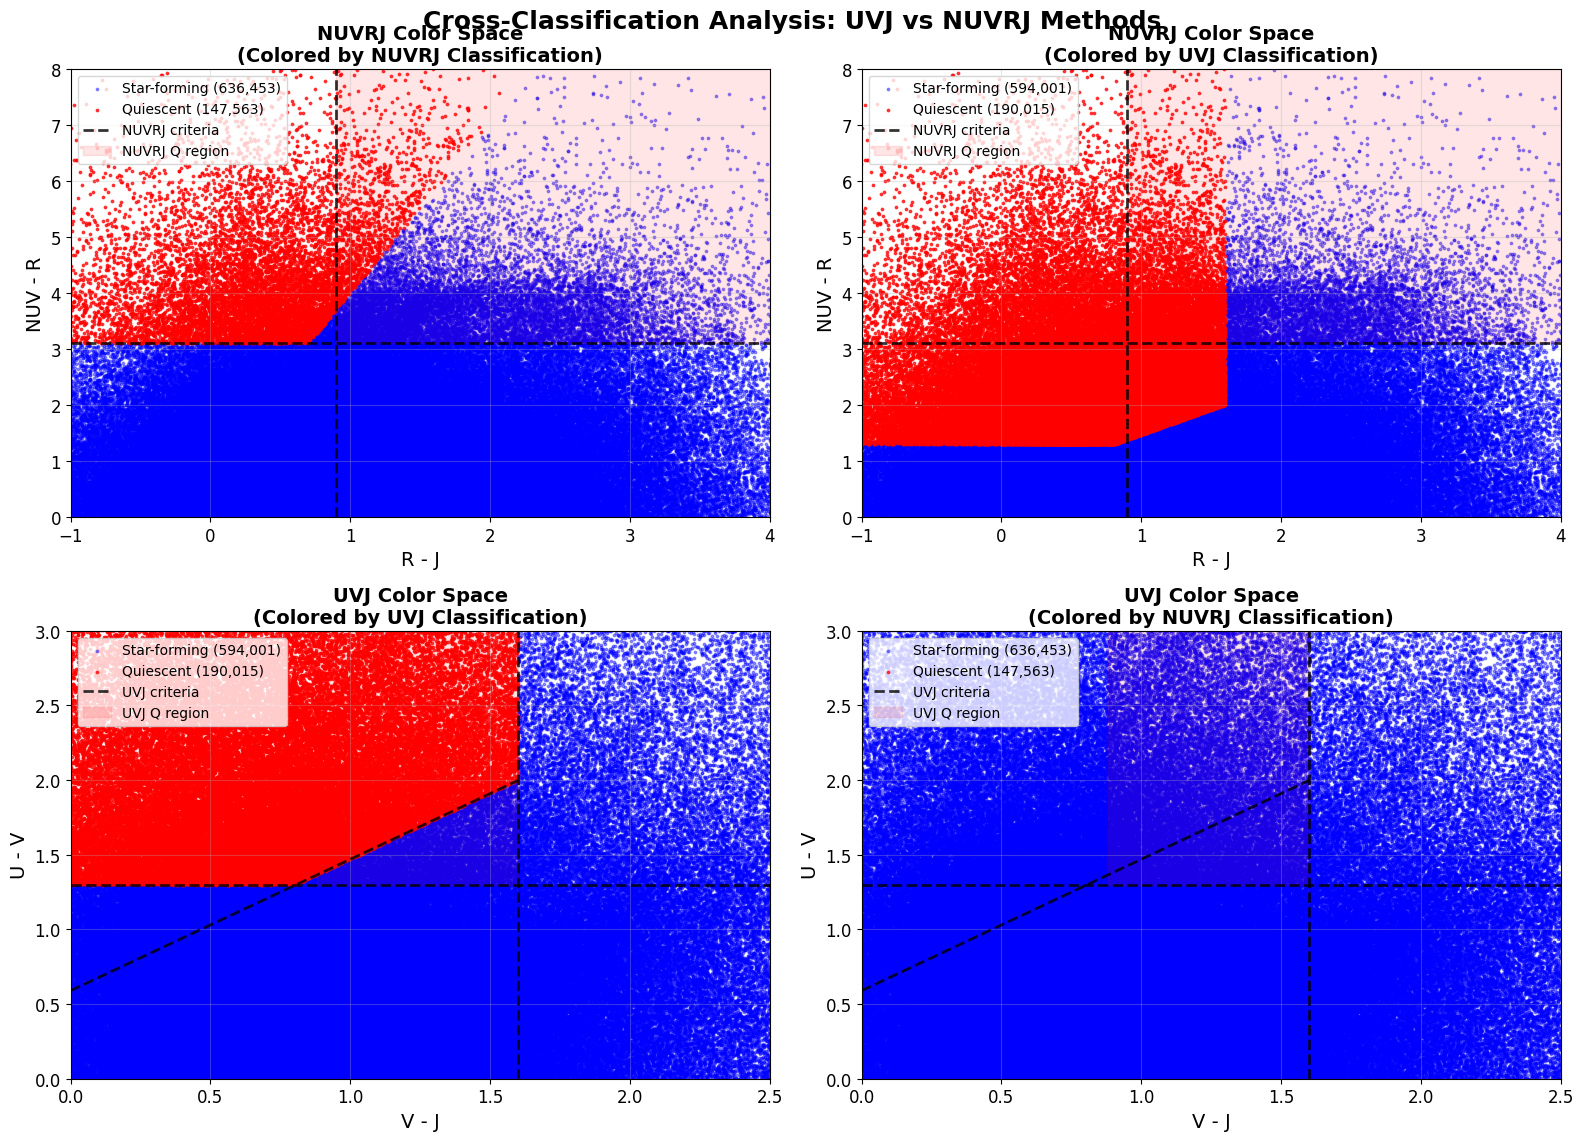

In [23]:
#%%
# =============================================================================
# 📈 CREATE 2x2 CROSS-CLASSIFICATION FIGURE
# =============================================================================

print(f"\n📈 Creating 2x2 cross-classification figure...")

# Create the figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define colors for classifications
colors = {0: 'blue', 1: 'red'}  # 0=SF (blue), 1=Q (red)
labels = {0: 'Star-forming', 1: 'Quiescent'}
alphas = {0: 0.4, 1: 0.7}  # SF more transparent, Q more opaque

#%%
# Plot 1: NUVRJ color space, colored by NUVRJ classification
ax = axes[0, 0]

if nuvrj_plot_valid.sum() > 0:
    # Get valid data
    nuv_r_valid = nuv_r[nuvrj_plot_valid]
    r_j_valid = r_j[nuvrj_plot_valid]
    nuvrj_class_valid_data = nuvrj_class[nuvrj_plot_valid]
    
    # Plot each classification
    for class_val in [0, 1]:  # SF first, then Q (so Q appears on top)
        mask = nuvrj_class_valid_data == class_val
        if mask.sum() > 0:
            ax.scatter(r_j_valid[mask], nuv_r_valid[mask], 
                      c=colors[class_val], alpha=alphas[class_val], s=3,
                      label=f'{labels[class_val]} ({mask.sum():,})')
    
    # Add NUVRJ criteria lines
    ax.axvline(x=0.9, color='black', linestyle='--', alpha=0.8, linewidth=2, label='NUVRJ criteria')
    ax.axhline(y=3.1, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Highlight quiescent region
    ax.fill([0.9, 4.5, 4.5, 0.9], [3.1, 3.1, 8, 8], 
            color='red', alpha=0.1, label='NUVRJ Q region')
    
    # Set limits and labels
    ax.set_xlim(-1, 4)
    ax.set_ylim(0, 8)
    
else:
    ax.text(0.5, 0.5, 'No valid data\nfor this plot', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)

ax.set_xlabel('R - J', fontsize=14)
ax.set_ylabel('NUV - R', fontsize=14)
ax.set_title('NUVRJ Color Space\n(Colored by NUVRJ Classification)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

#%%
# Plot 2: NUVRJ color space, colored by UVJ classification  
ax = axes[0, 1]

if nuvrj_plot_valid.sum() > 0:
    # Get valid data
    nuv_r_valid = nuv_r[nuvrj_plot_valid]
    r_j_valid = r_j[nuvrj_plot_valid]
    uvj_class_valid_data = uvj_class[nuvrj_plot_valid]  # Note: UVJ classification
    
    # Plot each classification
    for class_val in [0, 1]:
        mask = uvj_class_valid_data == class_val
        if mask.sum() > 0:
            ax.scatter(r_j_valid[mask], nuv_r_valid[mask], 
                      c=colors[class_val], alpha=alphas[class_val], s=3,
                      label=f'{labels[class_val]} ({mask.sum():,})')
    
    # Add NUVRJ criteria lines for reference
    ax.axvline(x=0.9, color='black', linestyle='--', alpha=0.8, linewidth=2, label='NUVRJ criteria')
    ax.axhline(y=3.1, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Highlight quiescent region
    ax.fill([0.9, 4.5, 4.5, 0.9], [3.1, 3.1, 8, 8], 
            color='red', alpha=0.1, label='NUVRJ Q region')
    
    ax.set_xlim(-1, 4)
    ax.set_ylim(0, 8)
    
else:
    ax.text(0.5, 0.5, 'No valid data\nfor this plot', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)

ax.set_xlabel('R - J', fontsize=14)
ax.set_ylabel('NUV - R', fontsize=14)
ax.set_title('NUVRJ Color Space\n(Colored by UVJ Classification)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

#%%
# Plot 3: UVJ color space, colored by UVJ classification
ax = axes[1, 0]

if uvj_plot_valid.sum() > 0:
    # Get valid data
    u_v_valid = u_v[uvj_plot_valid]
    v_j_valid = v_j[uvj_plot_valid]
    uvj_class_valid_data = uvj_class[uvj_plot_valid]
    
    # Plot each classification
    for class_val in [0, 1]:
        mask = uvj_class_valid_data == class_val
        if mask.sum() > 0:
            ax.scatter(v_j_valid[mask], u_v_valid[mask], 
                      c=colors[class_val], alpha=alphas[class_val], s=3,
                      label=f'{labels[class_val]} ({mask.sum():,})')
    
    # Add UVJ criteria lines (Whitaker et al. 2011)
    ax.axhline(y=1.3, color='black', linestyle='--', alpha=0.8, linewidth=2, label='UVJ criteria')
    ax.axvline(x=1.6, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Diagonal line: U-V = 0.88*V-J + 0.59
    v_j_diag = np.linspace(0, 1.6, 100)
    u_v_diag = 0.88 * v_j_diag + 0.59
    ax.plot(v_j_diag, u_v_diag, 'k--', alpha=0.8, linewidth=2)
    
    # Highlight quiescent region (simplified)
    v_j_fill = [0.88, 1.6, 1.6, 0.88]
    u_v_fill = [1.3, 1.3, 3.0, 3.0]
    ax.fill(v_j_fill, u_v_fill, color='red', alpha=0.1, label='UVJ Q region')
    
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, 3.0)
    
else:
    ax.text(0.5, 0.5, 'No valid data\nfor this plot', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)

ax.set_xlabel('V - J', fontsize=14)
ax.set_ylabel('U - V', fontsize=14)
ax.set_title('UVJ Color Space\n(Colored by UVJ Classification)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

#%%
# Plot 4: UVJ color space, colored by NUVRJ classification
ax = axes[1, 1]

if uvj_plot_valid.sum() > 0:
    # Get valid data
    u_v_valid = u_v[uvj_plot_valid]
    v_j_valid = v_j[uvj_plot_valid]
    nuvrj_class_valid_data = nuvrj_class[uvj_plot_valid]  # Note: NUVRJ classification
    
    # Plot each classification
    for class_val in [0, 1]:
        mask = nuvrj_class_valid_data == class_val
        if mask.sum() > 0:
            ax.scatter(v_j_valid[mask], u_v_valid[mask], 
                      c=colors[class_val], alpha=alphas[class_val], s=3,
                      label=f'{labels[class_val]} ({mask.sum():,})')
    
    # Add UVJ criteria lines for reference
    ax.axhline(y=1.3, color='black', linestyle='--', alpha=0.8, linewidth=2, label='UVJ criteria')
    ax.axvline(x=1.6, color='black', linestyle='--', alpha=0.8, linewidth=2)
    
    # Diagonal line
    v_j_diag = np.linspace(0, 1.6, 100)
    u_v_diag = 0.88 * v_j_diag + 0.59
    ax.plot(v_j_diag, u_v_diag, 'k--', alpha=0.8, linewidth=2)
    
    # Highlight quiescent region
    v_j_fill = [0.88, 1.6, 1.6, 0.88]
    u_v_fill = [1.3, 1.3, 3.0, 3.0]
    ax.fill(v_j_fill, u_v_fill, color='red', alpha=0.1, label='UVJ Q region')
    
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, 3.0)
    
else:
    ax.text(0.5, 0.5, 'No valid data\nfor this plot', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)

ax.set_xlabel('V - J', fontsize=14)
ax.set_ylabel('U - V', fontsize=14)
ax.set_title('UVJ Color Space\n(Colored by NUVRJ Classification)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

#%%
# Add overall figure title and layout
fig.suptitle('Cross-Classification Analysis: UVJ vs NUVRJ Methods', 
             fontsize=18, fontweight='bold', y=0.95)

plt.tight_layout()
plt.subplots_adjust(top=0.90)  # Make room for main title
plt.show()


In [24]:
#%%
# =============================================================================
# 📊 QUANTITATIVE DISAGREEMENT ANALYSIS
# =============================================================================

print(f"\n📊 QUANTITATIVE DISAGREEMENT ANALYSIS")
print("="*50)

if both_class_valid.sum() > 0:
    # Get sources with both classifications
    uvj_both = uvj_class[both_class_valid]
    nuvrj_both = nuvrj_class[both_class_valid]
    
    # Count disagreement types
    uvj_sf_nuvrj_q = ((uvj_both == 0) & (nuvrj_both == 1)).sum()
    uvj_q_nuvrj_sf = ((uvj_both == 1) & (nuvrj_both == 0)).sum()
    total_disagreements = uvj_sf_nuvrj_q + uvj_q_nuvrj_sf
    
    print(f"Sources with both classifications: {both_class_valid.sum():,}")
    print(f"Total disagreements: {total_disagreements:,} ({total_disagreements/both_class_valid.sum()*100:.1f}%)")
    print(f"  UVJ=SF, NUVRJ=Q: {uvj_sf_nuvrj_q:,} ({uvj_sf_nuvrj_q/both_class_valid.sum()*100:.2f}%)")
    print(f"  UVJ=Q, NUVRJ=SF: {uvj_q_nuvrj_sf:,} ({uvj_q_nuvrj_sf/both_class_valid.sum()*100:.2f}%)")
    
    # Which method is more conservative?
    if uvj_sf_nuvrj_q > uvj_q_nuvrj_sf:
        print(f"\n🔍 NUVRJ is more conservative (finds more quiescent than UVJ)")
        print(f"   Excess quiescent: {uvj_sf_nuvrj_q - uvj_q_nuvrj_sf:,} sources")
    elif uvj_q_nuvrj_sf > uvj_sf_nuvrj_q:
        print(f"\n🔍 UVJ is more conservative (finds more quiescent than NUVRJ)")
        print(f"   Excess quiescent: {uvj_q_nuvrj_sf - uvj_sf_nuvrj_q:,} sources")
    else:
        print(f"\n⚖️  Both methods find similar numbers of quiescent galaxies")

#%%
# =============================================================================
# 🎯 INTERPRETATION GUIDE
# =============================================================================

print(f"\n🎯 INTERPRETATION GUIDE")
print("="*40)

print(f"📈 What to look for in the plots:")
print(f"")
print(f"🔵 Top Row (NUVRJ Color Space):")
print(f"  • Left: NUVRJ colors with NUVRJ labels (should show clean separation)")
print(f"  • Right: NUVRJ colors with UVJ labels (shows how UVJ performs in NUVRJ space)")
print(f"  • Compare: Red points should mostly be in upper-right region (NUV-R>3.1, R-J>0.9)")
print(f"")
print(f"🔵 Bottom Row (UVJ Color Space):")
print(f"  • Left: UVJ colors with UVJ labels (should show clean separation)")
print(f"  • Right: UVJ colors with NUVRJ labels (shows how NUVRJ performs in UVJ space)")
print(f"  • Compare: Red points should mostly be in upper-right region above UVJ lines")
print(f"")
print(f"🔍 Signs of good agreement:")
print(f"  • Similar distribution patterns between left/right plots in each row")
print(f"  • Red points concentrated in the expected quiescent regions")
print(f"  • Blue points avoiding the quiescent regions")
print(f"")
print(f"⚠️  Signs of disagreement:")
print(f"  • Different patterns between left/right plots")
print(f"  • Red points scattered outside quiescent regions")
print(f"  • Blue points appearing inside quiescent regions")

#%%
# =============================================================================
# 💾 SAVE RESULTS
# =============================================================================

# Uncomment to save the figure
"""
plt.savefig('uvj_nuvrj_cross_classification.png', dpi=150, bbox_inches='tight')
print(f"💾 Figure saved: uvj_nuvrj_cross_classification.png")
"""

# Uncomment to save disagreement analysis
"""
if both_class_valid.sum() > 0:
    disagreement_summary = {
        'total_sources': both_class_valid.sum(),
        'agreement_percent': agreement_pct,
        'uvj_sf_nuvrj_q': uvj_sf_nuvrj_q,
        'uvj_q_nuvrj_sf': uvj_q_nuvrj_sf,
        'total_disagreements': total_disagreements
    }
    
    import json
    with open('cross_classification_summary.json', 'w') as f:
        json.dump(disagreement_summary, f, indent=2)
    
    print(f"💾 Summary saved: cross_classification_summary.json")
"""

print(f"\n✨ Cross-classification analysis complete!")
print(f"💡 Use this visualization to understand how the two methods differ")
print(f"   and choose the most appropriate one for your stacking analysis.")


📊 QUANTITATIVE DISAGREEMENT ANALYSIS
Sources with both classifications: 784,016
Total disagreements: 120,146 (15.3%)
  UVJ=SF, NUVRJ=Q: 38,847 (4.95%)
  UVJ=Q, NUVRJ=SF: 81,299 (10.37%)

🔍 UVJ is more conservative (finds more quiescent than NUVRJ)
   Excess quiescent: 42,452 sources

🎯 INTERPRETATION GUIDE
📈 What to look for in the plots:

🔵 Top Row (NUVRJ Color Space):
  • Left: NUVRJ colors with NUVRJ labels (should show clean separation)
  • Right: NUVRJ colors with UVJ labels (shows how UVJ performs in NUVRJ space)
  • Compare: Red points should mostly be in upper-right region (NUV-R>3.1, R-J>0.9)

🔵 Bottom Row (UVJ Color Space):
  • Left: UVJ colors with UVJ labels (should show clean separation)
  • Right: UVJ colors with NUVRJ labels (shows how NUVRJ performs in UVJ space)
  • Compare: Red points should mostly be in upper-right region above UVJ lines

🔍 Signs of good agreement:
  • Similar distribution patterns between left/right plots in each row
  • Red points concentrated in 